In [1]:
import yaml
import pickle

In [2]:
config_file = "../config_multiscope/dot_multi_scale5k10k.yaml"#_base_10_1.yaml"
with open(config_file, 'r') as file:
    config = yaml.safe_load(file)

In [3]:
p_filename = "../" + config['experiment_name'] + "_ts.pkl"

with open(p_filename, 'rb') as file:
    src = pickle.load(file)
    dst = pickle.load(file)

In [4]:
dst['/tordata/config/group_0_user_0']

,text_len,count
time,,
2025-07-17 15:24:44.451,249,2
2025-07-17 15:24:47.784,1309,5
2025-07-17 15:24:51.117,801,2
2025-07-17 15:24:54.450,834,2
2025-07-17 15:24:57.783,0,0
...,...,...
2025-07-17 17:09:13.824,0,0
2025-07-17 17:09:17.157,0,0
2025-07-17 17:09:20.490,0,0


In [5]:
src['102.0.0.10']

,ip.len,tcp.dstport,tcp.ack,tcp.len,tcp.reassembled.length,tcp.time_relative,tcp.time_delta,count,ip.len_ISP1-all,tcp.dstport_ISP1-all,...,count_Service-2,ip.proto_Service-3,ip.len_Service-3,tcp.dstport_Service-3,tcp.ack_Service-3,tcp.len_Service-3,tcp.time_relative_Service-3,tcp.time_delta_Service-3,count_Service-3,frame.time
frame.time,,,,,,,,,,,,,,,,,,,,,
2025-07-17 15:17:47.826,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 15:17:47.826
2025-07-17 15:17:51.159,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 15:17:51.159
2025-07-17 15:17:54.492,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 15:17:54.492
2025-07-17 15:17:57.825,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 15:17:57.825
2025-07-17 15:18:01.158,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 15:18:01.158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-17 17:22:47.076,77896.0,9487348.0,3.567120e+05,54224.0,1242.0,120.984699,19.551601,454.0,25385.0,2878087.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 17:22:47.076
2025-07-17 17:22:50.409,70044.0,7919240.0,2.918270e+05,50412.0,1242.0,102.487694,16.066378,374.0,23277.0,2487972.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 17:22:50.409
2025-07-17 17:22:53.742,34076.0,5050194.0,1.386160e+05,21700.0,0.0,59.036375,12.081629,238.0,10515.0,1450690.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-07-17 17:22:53.742


In [54]:
import pandas as pd 

def ts2nccvec(ts: pd.core.frame.DataFrame):
    sample_offset = ((len(ts)-1)**0.5)
    return (ts - ts.mean()) / (ts.std()*sample_offset)
    
vec = ts2nccvec(dst['/tordata/config/group_0_user_0']["text_len"])
vec

time
2025-05-07 11:08:42.654    0.010454
2025-05-07 11:08:45.987    0.221625
2025-05-07 11:08:49.320    0.141886
2025-05-07 11:08:52.653    0.132428
2025-05-07 11:08:55.986   -0.003570
                             ...   
2025-05-07 12:53:12.027   -0.003570
2025-05-07 12:53:15.360   -0.003570
2025-05-07 12:53:18.693   -0.003570
2025-05-07 12:53:22.026   -0.003570
2025-05-07 12:53:25.359    0.041274
Name: text_len, Length: 1886, dtype: float64

In [55]:
import numpy as np
np.dot(vec.to_numpy(), vec.to_numpy())

np.float64(0.9999999999999992)

### Todo
- **Find way to align dataset**
    - chunk, fill zeros, etc
    - _Last big thing to do before all out test of method_
- Get end to end working
    - Send pcaps dfs through ncc GIS stuff
- Run new experiment loop
    - run through all features/combos and report metrics

In [56]:
scale_factor = 300
chunk_size = td = pd.Timedelta(1, "W")/scale_factor
chunk_size

Timedelta('0 days 00:33:36')

In [57]:
start = min([src[ip].index[0] for ip in src])
start

Timestamp('2025-05-07 10:55:46.065000')

In [58]:
# Fill zeros in missing indexes
full_index = pd.Index([])

for ip in src:
    full_index = full_index.union(src[ip].index)
    
for user in dst:
    full_index = full_index.union(dst[user].index)
print(full_index)
for ip in src:
    src[ip] = src[ip].reindex(full_index, fill_value=0)
    assert len(src[ip]) == len(full_index)

for user in dst:
    dst[user] = dst[user].reindex(full_index, fill_value=0)
    assert len(dst[user]) == len(full_index)

Index([2025-05-07 10:55:46.065000, 2025-05-07 10:55:49.398000,
       2025-05-07 10:55:52.731000, 2025-05-07 10:55:56.064000,
       2025-05-07 10:55:59.397000, 2025-05-07 10:56:02.730000,
       2025-05-07 10:56:06.063000, 2025-05-07 10:56:09.396000,
       2025-05-07 10:56:12.729000, 2025-05-07 10:56:16.062000,
       ...
       2025-05-07 15:42:24.345000, 2025-05-07 15:42:27.678000,
       2025-05-07 15:42:31.011000, 2025-05-07 15:42:34.344000,
       2025-05-07 15:42:37.677000, 2025-05-07 15:42:41.010000,
       2025-05-07 15:42:44.343000, 2025-05-07 15:42:47.676000,
       2025-05-07 15:42:51.009000, 2025-05-07 15:42:54.342000],
      dtype='object', length=5170)


In [59]:
src_chunks = {}

for ip in src:
    cur = start
    end = src[ip].index[-1]
    src_chunks[ip] = {}
    
    while cur < end:
        src_chunks[ip][cur] = src[ip][cur:cur+chunk_size]
        cur += chunk_size

dst_chunks = {}

for user in dst:
    cur = start
    end = dst[user].index[-1]
    dst_chunks[user] = {}
    
    while cur < end:
        dst_chunks[user][cur] = dst[user][cur:cur+chunk_size]
        cur += chunk_size

In [60]:
# - fill out zeros in the other timestamps for smaller chunks (could do this before or after chunking)
# - copy NCCTree class over
# - Send through as test (def eval(src_chunks[f], dst_chunks[f], label_func) -> List[Metrics] )
# - Setup experiment full loop (loop over all feature combos and multithread, save out to a file)

In [61]:
#dst_chunks['/tordata/config/group_0_user_0'][pd.Timestamp('2025-05-07 11:02:22.692000')]

In [62]:
def eval_model(src, src_feature, dst, dst_feature, label_func, metric_func) -> {str: float}:
    output = model(src, src_feature, dst, dst_feature)
    labels = label_func(src_chunks)
    return metric_func(output, labels)

In [63]:
import math
def ip_to_user_multi(ip, group_size=5, starting=10):
    num_isps = 10
    isp = int(int(ip.split(".")[-2]))
    node_number = (int(ip.split(".")[-1]) - starting )*num_isps + isp
    user = node_number % group_size
    group = math.floor(node_number / group_size)
    return '/tordata/config/group_' + str(group) + "_user_" + str(user)
    
def label_f(d) -> {str: str}:
    result = {}
    for k in d:
        result[k] = ip_to_user_multi(k)
    return result

print(src.keys())
print(ip_to_user_multi('102.0.8.13'))

dict_keys(['102.0.9.10', '102.0.6.14', '102.0.6.11', '102.0.7.16', '102.0.8.18', '102.0.6.13', '102.0.0.14', '102.0.4.17', '102.0.5.17', '102.0.2.12', '8.8.5.12', '102.0.9.19', '102.0.6.12', '102.0.3.12', '102.0.1.12', '102.0.3.14', '102.0.5.11', '102.0.0.11', '102.0.7.11', '102.0.9.11', '102.0.5.14', '102.0.2.10', '102.0.2.16', '102.0.6.10', '102.0.4.14', '102.0.5.13', '102.0.2.15', '102.0.1.11', '102.0.7.13', '102.0.6.17', '102.0.5.18', '102.0.3.18', '102.0.3.17', '102.0.5.12', '102.0.6.16', '102.0.3.19', '102.0.9.12', '102.0.8.17', '102.0.4.18', '102.0.8.19', '102.0.7.18', '102.0.4.12', '102.0.7.14', '102.0.0.18', '102.0.3.16', '102.0.2.17', '102.0.1.16', '102.0.7.17', '102.0.5.15', '102.0.7.10', '102.0.1.19', '102.0.9.15', '102.0.0.10', '8.8.5.11', '102.0.4.15', '102.0.2.14', '102.0.2.11', '102.0.4.11', '102.0.6.19', '8.8.5.13', '102.0.4.16', '102.0.1.15', '102.0.1.18', '102.0.9.18', '102.0.3.15', '102.0.9.17', '102.0.9.16', '102.0.0.15', '102.0.8.10', '102.0.0.13', '102.0.6.18', '

In [64]:
#from functools import lru_cache

#@lru_cache(maxsize=None) 
def metric_match(x, y, yi):
    return  x == y[yi][0]

#@lru_cache(maxsize=None) 
def accuracy(output, labels) -> float:
    if len(output) == 0:
        return 0.
    correct = 0.0
    for x in output:
        if metric_match(labels[x], output[x], 0):
            correct += 1.
    accuracy = correct/len(output)
    return accuracy

#@lru_cache(maxsize=None) 
def rank(output, labels) -> [float]:
    result = [0.]*len(output)
    
    for idx, x in enumerate(output):
        for yi in range(len(output[x])):
            if metric_match(labels[x], output[x], yi):
                result[idx] = yi + 1
                break
        if result[idx] == 0:
            print(x)
        #assert result[idx] != 0
                
    return result

#@lru_cache(maxsize=None) 
def recall_k_f(k):
    def recall_k(output, labels) -> float:
        ranks = rank(output, labels)
        # Must remove values that are 0. These are values that could not be found
        ranks = filter(lambda x: x != 0., ranks)
        return sum([1. if r <= k else 0. for r in ranks])/len(output)
    return recall_k

#@lru_cache(maxsize=None) 
def precision_k_f(k):  
    def precision_k(output, labels) -> float:
        return recall_k_f(k)(output, labels) / float(k)
    return precision_k

#@lru_cache(maxsize=None) 
def f_beta_k_f(k, beta=1.):  
    def f_beta_k(output, labels) -> float:
        recall = recall_k_f(k)(output, labels)
        precision = precision_k_f(k)(output, labels)
        top = (1. + beta * beta) * recall * precision 
        bottom = (beta * beta * precision) + recall
        if bottom == 0:
            return 0
        return top / bottom
    return f_beta_k

#@lru_cache(maxsize=None) 
def MRR(output, labels) -> float:
    ranks = rank(output, labels)
    # Must remove values that are 0. These are values that could not be found
    ranks = filter(lambda x: x != 0., ranks)
    return sum([1./r for r in ranks])/len(output)

In [65]:
def all_metrics(output, labels):
    metrics = [
        ("Accuracy", accuracy),
        
        ("Recall@1", recall_k_f(1)),
        ("Recall@2", recall_k_f(2)),
        ("Recall@4", recall_k_f(4)),
        ("Recall@8", recall_k_f(8)),
        
        ("Precision@1", precision_k_f(1)),
        ("Precision@2", precision_k_f(2)),
        ("Precision@4", precision_k_f(4)),
        ("Precision@8", precision_k_f(8)),

        ("F-beta@1", f_beta_k_f(1)),
        ("F-beta@2", f_beta_k_f(2)),
        ("F-beta@4", f_beta_k_f(4)),
        ("F-beta@8", f_beta_k_f(8)),

        ("MRR", MRR),

        ("Rank", rank)
    ]

    return {m[0]: m[1](output, labels) for m in metrics}
    
def get_metric_names(m_f):
    return list(m_f({"": [("", 1)]}, {"": ""}).keys())


In [66]:
import sys
import os
from tqdm import tqdm
sys.path.append("./NCC")
from NCC import NCCTree

def get_ts(p, feature, defualt_size):
    if feature not in p:
        return np.zeros(defualt_size)
    #time = pd.Timestamp('2025-05-07 11:02:22.692000')
    #return p[time][feature].to_numpy()
    return p[feature].to_numpy()

def model(src_chunks, src_feature, dst_chunks, dst_feature, disable_bar=True) -> {str: [(str, float)]}:
    result = {}
    ts_size = len(src_chunks[list(src_chunks.keys())[0]])

    #noise_floor = np.mean([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])
    
    tree = NCCTree(ts_size)
    for p in tqdm(dst_chunks, disable=disable_bar):
        ts = get_ts(dst_chunks[p], dst_feature, ts_size)
        # advoid divide by zero if all zeros 
        #if (ts == 0).all(): continue
        vec = ts2nccvec(ts)
        assert abs(1 - np.linalg.norm(vec)) < 0.001
        tree.insert(vec, p)

    #for _ in range(10):
    for p in tqdm(src_chunks, disable=disable_bar):
        ts = get_ts(src_chunks[p], src_feature, ts_size)
        #if (ts == 0).all(): continue
        vec = ts2nccvec(ts)
        #vec[vec < noise_floor] = 0
        n = tree.ncc(vec, 100)
        #print(ip_to_user_multi(p), n)
        result[p] = n
    
    # if in and out are set to the same then this confirms it works correctly
    # assert(all(n[i] >= n[i + 1] for i in range(len(n) - 1)))
    
    return result
#out = model(src, 'count_ISP1-3', dst, 'count')

In [67]:
%%time
eval_model(src, 'count', dst, 'count', label_f, all_metrics)

CPU times: user 835 ms, sys: 996 μs, total: 836 ms
Wall time: 844 ms


{'Accuracy': 0.9615384615384616,
 'Recall@1': 0.9615384615384616,
 'Recall@2': 0.9615384615384616,
 'Recall@4': 0.9615384615384616,
 'Recall@8': 0.9615384615384616,
 'Precision@1': 0.9615384615384616,
 'Precision@2': 0.4807692307692308,
 'Precision@4': 0.2403846153846154,
 'Precision@8': 0.1201923076923077,
 'F-beta@1': 0.9615384615384616,
 'F-beta@2': 0.6410256410256411,
 'F-beta@4': 0.38461538461538464,
 'F-beta@8': 0.2136752136752137,
 'MRR': 0.9625333487745665,
 'Rank': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  61,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  30,
  1,
  1,
  1,
  1,
  1,
  30,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  49,
  1,
  1,
  1,
  1,
  1,
  1,
  1

In [68]:
def eval_all(src, dst, label_f, metric_f):
    src_features = set([])
    for x in list(src.values()):
        src_features |= set(x.columns)
        
    dst_features = set([])
    for x in list(dst.values()):
        dst_features |= set(x.columns)
    bad_features = ['frame.time']

    metric_names = get_metric_names(metric_f)

    results = pd.DataFrame(columns=['src_feature', 'dst_feature'] + metric_names)
    for df in dst_features:
        for sf in tqdm(src_features):
            if sf in bad_features: continue
            results.loc[len(results)] = {
                'src_feature': sf, 
                'dst_feature': df,
            } | eval_model(src, sf, dst, df, label_f, metric_f)
    return results

model_all_out = eval_all(src, dst, label_f, all_metrics)
model_all_out

  0%|                                                                                                                                                                                                                              | 0/119 [00:00<?, ?it/s]/tmp/ipykernel_1915941/1028957165.py:5: RuntimeWarning: invalid value encountered in divide
  return (ts - ts.mean()) / (ts.std()*sample_offset)
  1%|█▊                                                                                                                                                                                                                    | 1/119 [00:00<01:40,  1.17it/s]/tmp/ipykernel_1915941/1028957165.py:5: RuntimeWarning: invalid value encountered in divide
  return (ts - ts.mean()) / (ts.std()*sample_offset)
  2%|███▌                                                                                                                                                                                                       

,src_feature,dst_feature,Accuracy,Recall@1,Recall@2,Recall@4,Recall@8,Precision@1,Precision@2,Precision@4,Precision@8,F-beta@1,F-beta@2,F-beta@4,F-beta@8,MRR,Rank
0,tcp.ack_resolver-2,count,0.067308,0.067308,0.115385,0.134615,0.230769,0.067308,0.057692,0.033654,0.028846,0.067308,0.076923,0.053846,0.051282,0.139739,"[34, 87, 95, 37, 59, 44, 29, 21, 78, 33, 85, 1..."
1,tcp.ack_ISP1-all,count,0.105769,0.105769,0.125000,0.144231,0.182692,0.105769,0.062500,0.036058,0.022837,0.105769,0.083333,0.057692,0.040598,0.149150,"[4, 69, 95, 45, 37, 47, 1, 28, 33, 92, 85, 15,..."
2,tcp.time_relative_ISP1-1,count,0.009615,0.009615,0.028846,0.048077,0.076923,0.009615,0.014423,0.012019,0.009615,0.009615,0.019231,0.019231,0.017094,0.053961,"[4, 69, 95, 45, 37, 47, 54, 28, 33, 92, 85, 15..."
3,udp.dstport_resolver-3,count,0.009615,0.009615,0.028846,0.048077,0.086538,0.009615,0.014423,0.012019,0.010817,0.009615,0.019231,0.019231,0.019231,0.055030,"[4, 69, 95, 45, 37, 47, 74, 28, 33, 92, 85, 15..."
4,tcp.dstport_resolver-3,count,0.932692,0.932692,0.951923,0.961538,0.971154,0.932692,0.475962,0.240385,0.121394,0.932692,0.634615,0.384615,0.215812,0.947058,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 85, 1, 1, 1, 1,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,tcp.time_relative_resolver-2,text_len,0.038462,0.038462,0.057692,0.067308,0.125000,0.038462,0.028846,0.016827,0.015625,0.038462,0.038462,0.026923,0.027778,0.085197,"[21, 32, 90, 54, 76, 39, 50, 9, 77, 17, 85, 12..."
232,ip.len,text_len,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,0.480769,0.240385,0.120192,0.961538,0.641026,0.384615,0.213675,0.962397,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 65, 1, 1, 1, 1,..."
233,tcp.ack_ISP1-1,text_len,0.028846,0.028846,0.076923,0.105769,0.163462,0.028846,0.038462,0.026442,0.020433,0.028846,0.051282,0.042308,0.036325,0.093732,"[4, 69, 95, 45, 37, 47, 3, 28, 33, 92, 85, 15,..."
234,ip.len_resolver-all,text_len,0.932692,0.932692,0.951923,0.971154,0.971154,0.932692,0.475962,0.242788,0.121394,0.932692,0.634615,0.388462,0.215812,0.948260,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 85, 1, 1, 1, 1,..."


In [69]:
model_all_out.to_csv(config_file + '.csv', index=False)
model_all_out.sort_values(by='Accuracy', ascending=False)

,src_feature,dst_feature,Accuracy,Recall@1,Recall@2,Recall@4,Recall@8,Precision@1,Precision@2,Precision@4,Precision@8,F-beta@1,F-beta@2,F-beta@4,F-beta@8,MRR,Rank
10,tcp.len_Service-2,count,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,0.480769,0.240385,0.120192,0.961538,0.641026,0.384615,0.213675,0.962102,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 62, 1, 1, 1, 1,..."
5,count,count,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,0.480769,0.240385,0.120192,0.961538,0.641026,0.384615,0.213675,0.962533,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 61, 1, 1, 1, 1,..."
16,tcp.ack_Service-all,count,0.961538,0.961538,0.971154,0.971154,0.971154,0.961538,0.485577,0.242788,0.121394,0.961538,0.647436,0.388462,0.215812,0.966690,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 85, 1, 1, 1, 1,..."
14,tcp.len_Service-all,count,0.961538,0.961538,0.971154,0.971154,0.971154,0.961538,0.485577,0.242788,0.121394,0.961538,0.647436,0.388462,0.215812,0.966690,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 85, 1, 1, 1, 1,..."
37,tcp.len_Service-3,count,0.961538,0.961538,0.961538,0.961538,0.961538,0.961538,0.480769,0.240385,0.120192,0.961538,0.641026,0.384615,0.213675,0.962276,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 85, 1, 1, 1, 1,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,count_cache,text_len,0.000000,0.000000,0.019231,0.019231,0.019231,0.000000,0.009615,0.004808,0.002404,0.000000,0.012821,0.007692,0.004274,0.033748,"[84, 41, 35, 90, 47, 64, 64, 15, 9, 45, 85, 94..."
164,count_cache_root,text_len,0.000000,0.000000,0.009615,0.009615,0.019231,0.000000,0.004808,0.002404,0.002404,0.000000,0.006410,0.003846,0.004274,0.030358,"[99, 41, 24, 86, 29, 68, 62, 16, 25, 35, 85, 9..."
200,count_cache_TLD,text_len,0.000000,0.000000,0.009615,0.009615,0.038462,0.000000,0.004808,0.002404,0.004808,0.000000,0.006410,0.003846,0.008547,0.031981,"[51, 61, 29, 87, 74, 66, 63, 52, 13, 63, 85, 8..."
208,udp.dstport_root,text_len,0.000000,0.000000,0.019231,0.038462,0.067308,0.000000,0.009615,0.009615,0.008413,0.000000,0.012821,0.015385,0.014957,0.043048,"[92, 76, 19, 100, 58, 28, 60, 61, 13, 2, 85, 7..."


In [70]:
def best_scopes(results):
    pass

In [71]:
def smallest_gt_zero(df):
    return min(df[df > 0])
#smallest_gt_zero(y2)

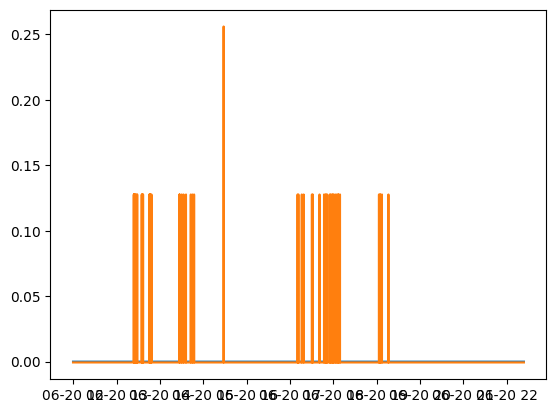

np.float64(0.0)

In [24]:
import matplotlib.pyplot as plt
import datetime

noise_floor = np.mean([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])

x = src['102.0.0.10'].index
y = ts2nccvec(src['102.0.0.10']['count'])
y2 = ts2nccvec(dst['/tordata/config/group_0_user_0']['count'])

y.loc[y < noise_floor] = 0


plt.plot(x,y)
plt.plot(x, y2)
plt.show()
np.dot(y.to_numpy(), y2.to_numpy())#/np.dot(y.to_numpy(), y.to_numpy())

In [25]:
pd.unique(y2)
y2

2025-06-20 11:59:49.014   -0.000674
2025-06-20 11:59:52.347   -0.000674
2025-06-20 11:59:55.680   -0.000674
2025-06-20 11:59:59.013   -0.000674
2025-06-20 12:00:02.346   -0.000674
                             ...   
2025-06-20 22:23:28.605   -0.000674
2025-06-20 22:23:31.938   -0.000674
2025-06-20 22:23:35.271   -0.000674
2025-06-20 22:23:38.604   -0.000674
2025-06-20 22:23:41.937   -0.000674
Name: count, Length: 11232, dtype: float64

In [26]:
np.min([smallest_gt_zero(ts2nccvec(dst[user]['count'])) for user in dst])

np.float64(0.08022668076674895)

In [27]:
list(src['102.0.0.10'].columns)

['ip.proto',
 'ip.len',
 'tcp.dstport',
 'tcp.ack',
 'tcp.len',
 'tcp.reassembled.length',
 'udp.dstport',
 'tcp.time_relative',
 'tcp.time_delta',
 'count',
 'ip.proto_ISP1-all',
 'ip.len_ISP1-all',
 'tcp.dstport_ISP1-all',
 'tcp.ack_ISP1-all',
 'tcp.len_ISP1-all',
 'tcp.reassembled.length_ISP1-all',
 'udp.dstport_ISP1-all',
 'tcp.time_relative_ISP1-all',
 'tcp.time_delta_ISP1-all',
 'count_ISP1-all',
 'ip.proto_ISP1-3',
 'ip.len_ISP1-3',
 'tcp.dstport_ISP1-3',
 'tcp.ack_ISP1-3',
 'tcp.len_ISP1-3',
 'udp.dstport_ISP1-3',
 'tcp.time_relative_ISP1-3',
 'tcp.time_delta_ISP1-3',
 'count_ISP1-3',
 'ip.proto_resolver-all',
 'ip.len_resolver-all',
 'udp.dstport_resolver-all',
 'count_resolver-all',
 'ip.proto_resolver-1',
 'ip.len_resolver-1',
 'tcp.dstport_resolver-1',
 'tcp.ack_resolver-1',
 'tcp.len_resolver-1',
 'udp.dstport_resolver-1',
 'tcp.time_relative_resolver-1',
 'tcp.time_delta_resolver-1',
 'count_resolver-1',
 'count_cache',
 'ip.proto_root',
 'ip.len_root',
 'udp.dstport_root

In [28]:
def model_OLD(src_raw, src_feature, dst_raw, dst_feature):
    import statsmodels.api as sm
    def ccf_calc(sig1, sig2):
        corr = sm.tsa.stattools.ccf(sig2, sig1, adjusted=False, nlags=1)
    
        # Remove padding and reverse the order
        return corr[0:(len(sig2)+1)][::-1]


    def cross_cor(ts1, ts2, debug=False, max_offset=300, only_positive=True):
        ccf = ccf_calc(ts1, ts2)
        best_cor = max(ccf)
        best_lag = np.argmax(ccf)
    
        if debug:
            print('best cross correlation: ' + str(best_cor) + " at time lag: " + str(best_lag))
            print(len(ccf))
            print(ccf)
            ccf_plot(range(len(ccf)), ccf)
        return best_cor, best_lag

    def compare_ts(ts1, ts2, debug=False):
        # dtw_classic, path_classic = dtw(ts1, ts2, dist='square',
        #                             method='classic', return_path=True)
        # return dtw_classic
        # print(ts1)
        # print(ts2)
        # dist, lag = cross_cor(pd.Series(ts1), pd.Series(ts2))
        dist, lag = cross_cor(ts1, ts2, debug=debug)
        # assert dist >= -1 and dist <= 1
        dist = dist * -1  # flip for use as distance metric
        # assert dist >= -1 and dist <= 1
        return dist, lag

    def compare_ts_reshape(ts1, ts2, debug=False):
        ts1 = ts1.fillna(0)
        ts2 = ts2.fillna(0)
    
        range = min(ts2.index.values), max(ts2.index.values)
        ts1 = ts1.loc[(ts1.index >= range[0]) & (ts1.index <= range[1])]
    
        # ts1 = ts1.loc[:, 'tda_pl']
        ts1 = ts1.values
    
        ts1_norm = np.array(ts1)
        ts2_norm = np.array(ts2)
    
        # delay = 0
    
        # ts1_norm.index = ts1_norm.index + pd.DateOffset(seconds=delay)
    
        # lock to same range with buffer room
        # on each side to account for network (or PPT) delay
    
        # detect if no overlap
        if len(ts1_norm) < 2 or len(ts2_norm) < 2:
            return float("inf"), 0
    
        # Normalize peaks?
        # ts1_norm = normalize_ts(ts1_norm)
        # ts2_norm = normalize_ts(ts2_norm)
    
        # plot_ts(ts1_norm, ts2_norm)
        # exit(1)
    
        # else:
        #     ts1_norm = ts1_norm.tolist()
        #     ts2_norm = ts2_norm.tolist()
    
        score, lag = compare_ts(ts1_norm, ts2_norm, debug=debug)
        # adj_score = score + (((lag+1)**1.1)/1000.0)
        return score, lag

    src = {}
    dst = {}
    for ip in src_raw:
        src[ip] = src_raw[ip][src_feature]
    for user in dst_raw:
        dst[user] = dst_raw[user][dst_feature]
        
    correct = 0.0
    for user in dst:
        best_score = 0
        best_user = 0
        #for _ in range(10):
        for ip in src:
            score = sm.tsa.stattools.ccf(src[ip].values, dst[user].values, adjusted=False, nlags=1)
            if score > best_score:
                best_score = score
                best_user = ip_to_user_multi(ip)
        if user == best_user:
            correct += 1
    accuracy = correct / len(src)
    return accuracy

In [29]:
%%time
model_OLD(src, 'count', dst, 'count')

CPU times: user 1.76 s, sys: 126 ms, total: 1.89 s
Wall time: 1.54 s


1.0